## 03 · Feature Analysis

**Goals**
1. Load the extracted feature CSV from Notebook 02.
2. Plot MFCC distributions per genre — which coefficients best separate genres?
3. Plot spectral feature boxplots (centroid, bandwidth, rolloff, tempo, ZCR, RMS).
4. Compute and visualise the **feature correlation matrix**.
5. Plot a **MFCC heatmap by genre** — average MFCC profile per genre.
6. Pairplot of selected features coloured by genre.

---
All plots are read-only (no model training). They inform feature selection and explain model behaviour.

**Expected output of this notebook:**
- 6 MFCC distribution histograms (one per coefficient, all genres overlaid)
- 6 spectral feature boxplots per genre
- 70×70 correlation heatmap
- MFCC genre heatmap (10 genres × 13 coefficients)
- Pairplot of 4 key features coloured by genre

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.data_loader import load_features
from src.config      import PRIMARY_COLOR, SECONDARY_COLOR

plt.rcParams["figure.dpi"] = 110
print("Imports OK")

Imports OK


---
## 1 · Load Features

In [2]:
df = load_features()
feature_cols = [c for c in df.columns if c not in ("genre", "filename")]

print(f"Genres  : {sorted(df['genre'].unique())}")
print(f"Features: {len(feature_cols)}")
display(df.head(3))

Loaded features: 999 samples × 72 columns
Genres  : ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Features: 70


,mfcc1_mean,mfcc2_mean,mfcc3_mean,mfcc4_mean,mfcc5_mean,mfcc6_mean,mfcc7_mean,mfcc8_mean,mfcc9_mean,mfcc10_mean,...,spectral_contrast7,zcr_mean,zcr_std,rms_mean,rms_std,tempo,harmony,perceptr,genre,filename
0,-113.619385,121.553017,-19.151056,42.345768,-6.371168,18.613033,-13.692060,15.339378,-12.283618,10.973776,...,39.667577,0.083066,0.027690,0.130192,0.053201,123.046875,-0.000045,0.000007,blues,blues.00000.wav
1,-207.581512,123.997147,8.939115,35.870758,2.919970,21.518787,-8.555368,23.355938,-10.101037,11.906445,...,37.518985,0.056044,0.038059,0.095892,0.048724,67.999589,0.000142,-0.000181,blues,blues.00001.wav
2,-90.776344,140.448608,-29.100559,31.687340,-13.975971,25.741686,-13.644712,11.623112,-11.775920,9.700466,...,39.035077,0.076301,0.031738,0.175494,0.052465,161.499023,0.000001,-0.000016,blues,blues.00002.wav


---
## 2 · MFCC Distributions by Genre

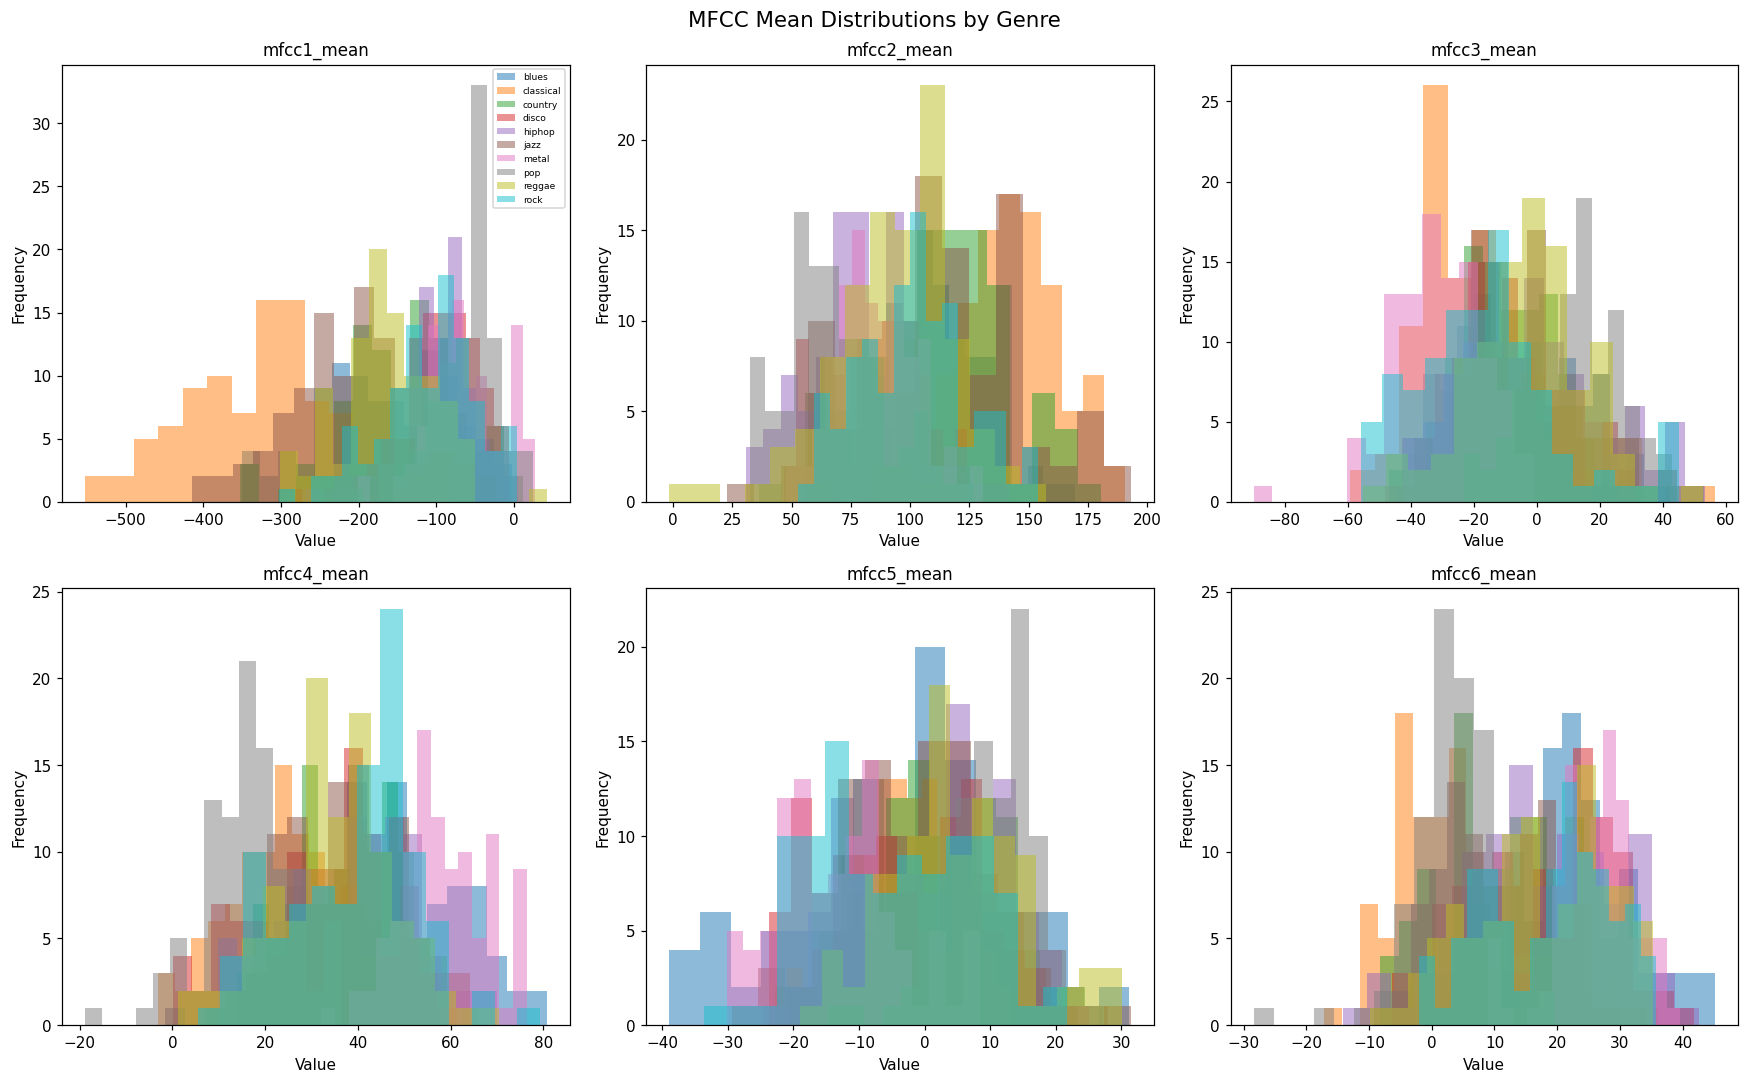

In [3]:
mfcc_mean_cols = [c for c in df.columns if "mfcc" in c and "mean" in c]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(mfcc_mean_cols[:6]):
    for genre in df["genre"].unique():
        subset = df[df["genre"] == genre][col]
        axes[i].hist(subset, alpha=0.5, label=genre, bins=15)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    if i == 0:
        axes[i].legend(fontsize=6, loc="upper right")

plt.suptitle("MFCC Mean Distributions by Genre", fontsize=14)
plt.tight_layout()
plt.show()

---
## 3 · Spectral Features Boxplot

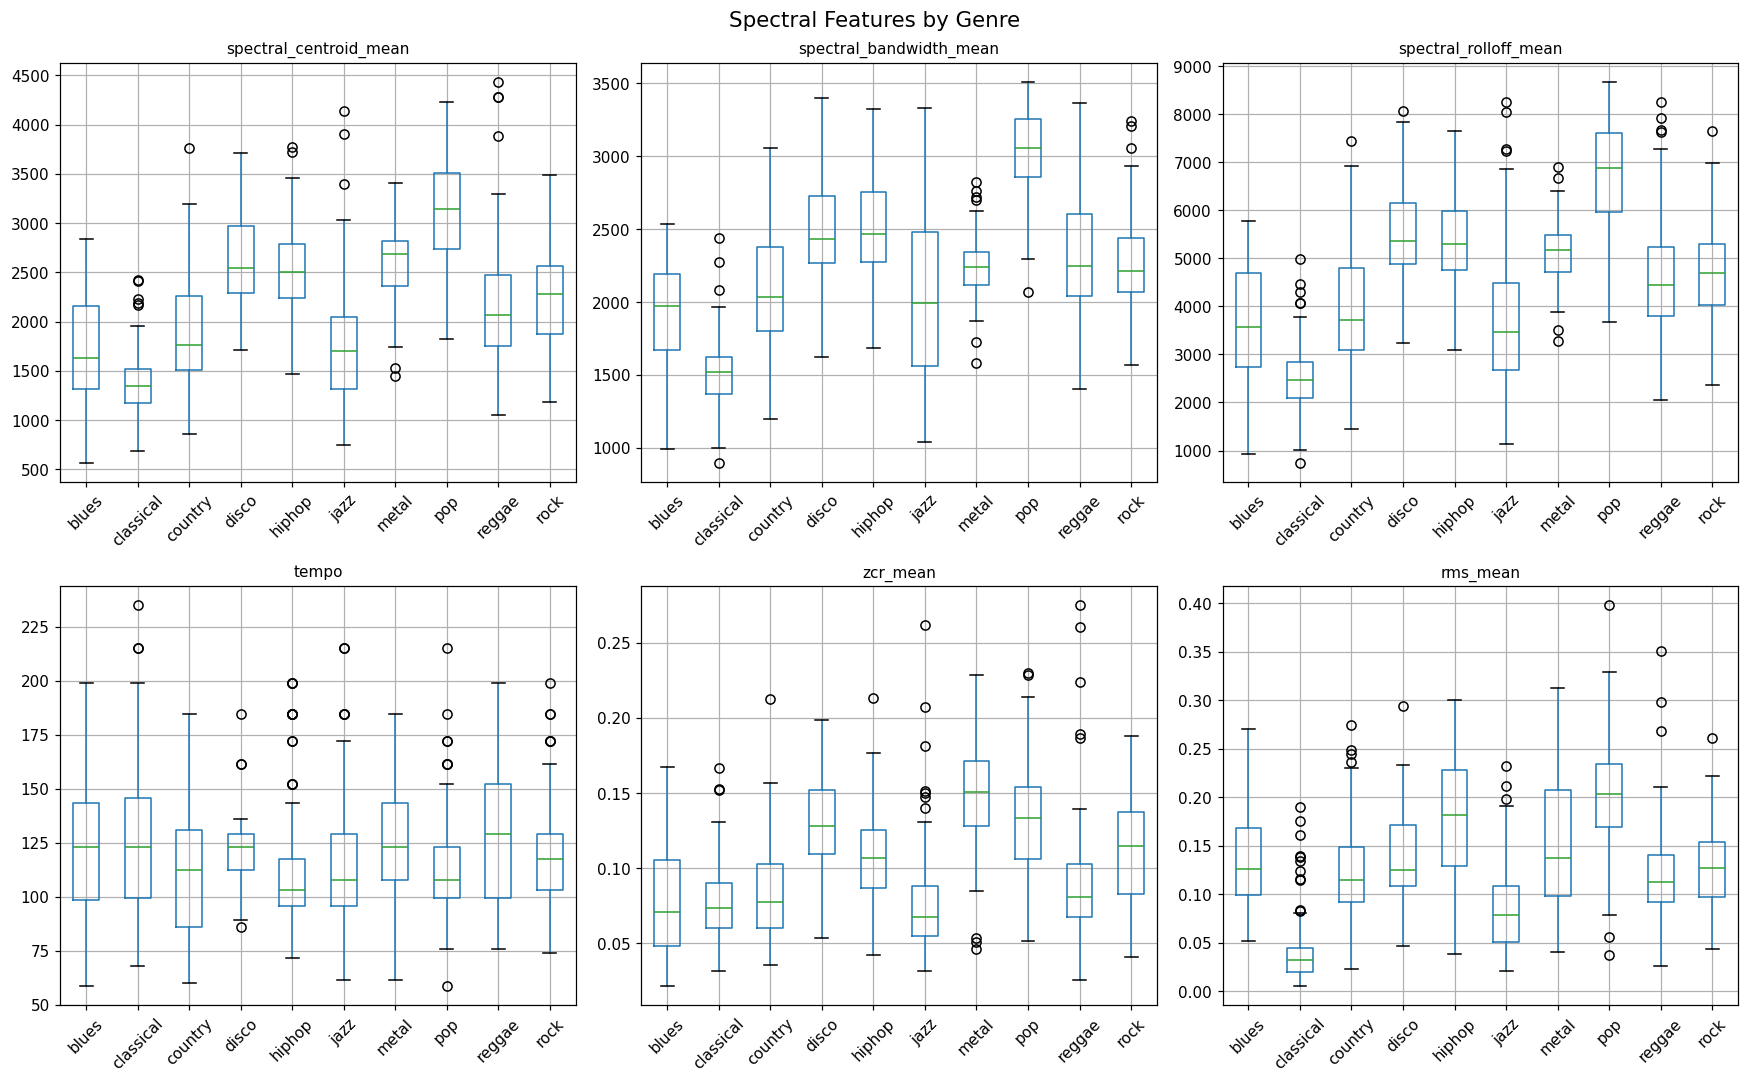

In [4]:
spectral_cols = [
    "spectral_centroid_mean", "spectral_bandwidth_mean",
    "spectral_rolloff_mean",  "tempo", "zcr_mean", "rms_mean"
]
existing = [c for c in spectral_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(existing[:6]):
    df.boxplot(column=col, by="genre", ax=axes[idx])
    axes[idx].set_title(col, fontsize=10)
    axes[idx].set_xlabel("")
    axes[idx].tick_params(axis="x", rotation=45)
for idx in range(len(existing), 6):
    axes[idx].set_visible(False)

plt.suptitle("Spectral Features by Genre", fontsize=14)
plt.tight_layout()
plt.show()

---
## 4 · Correlation Matrix

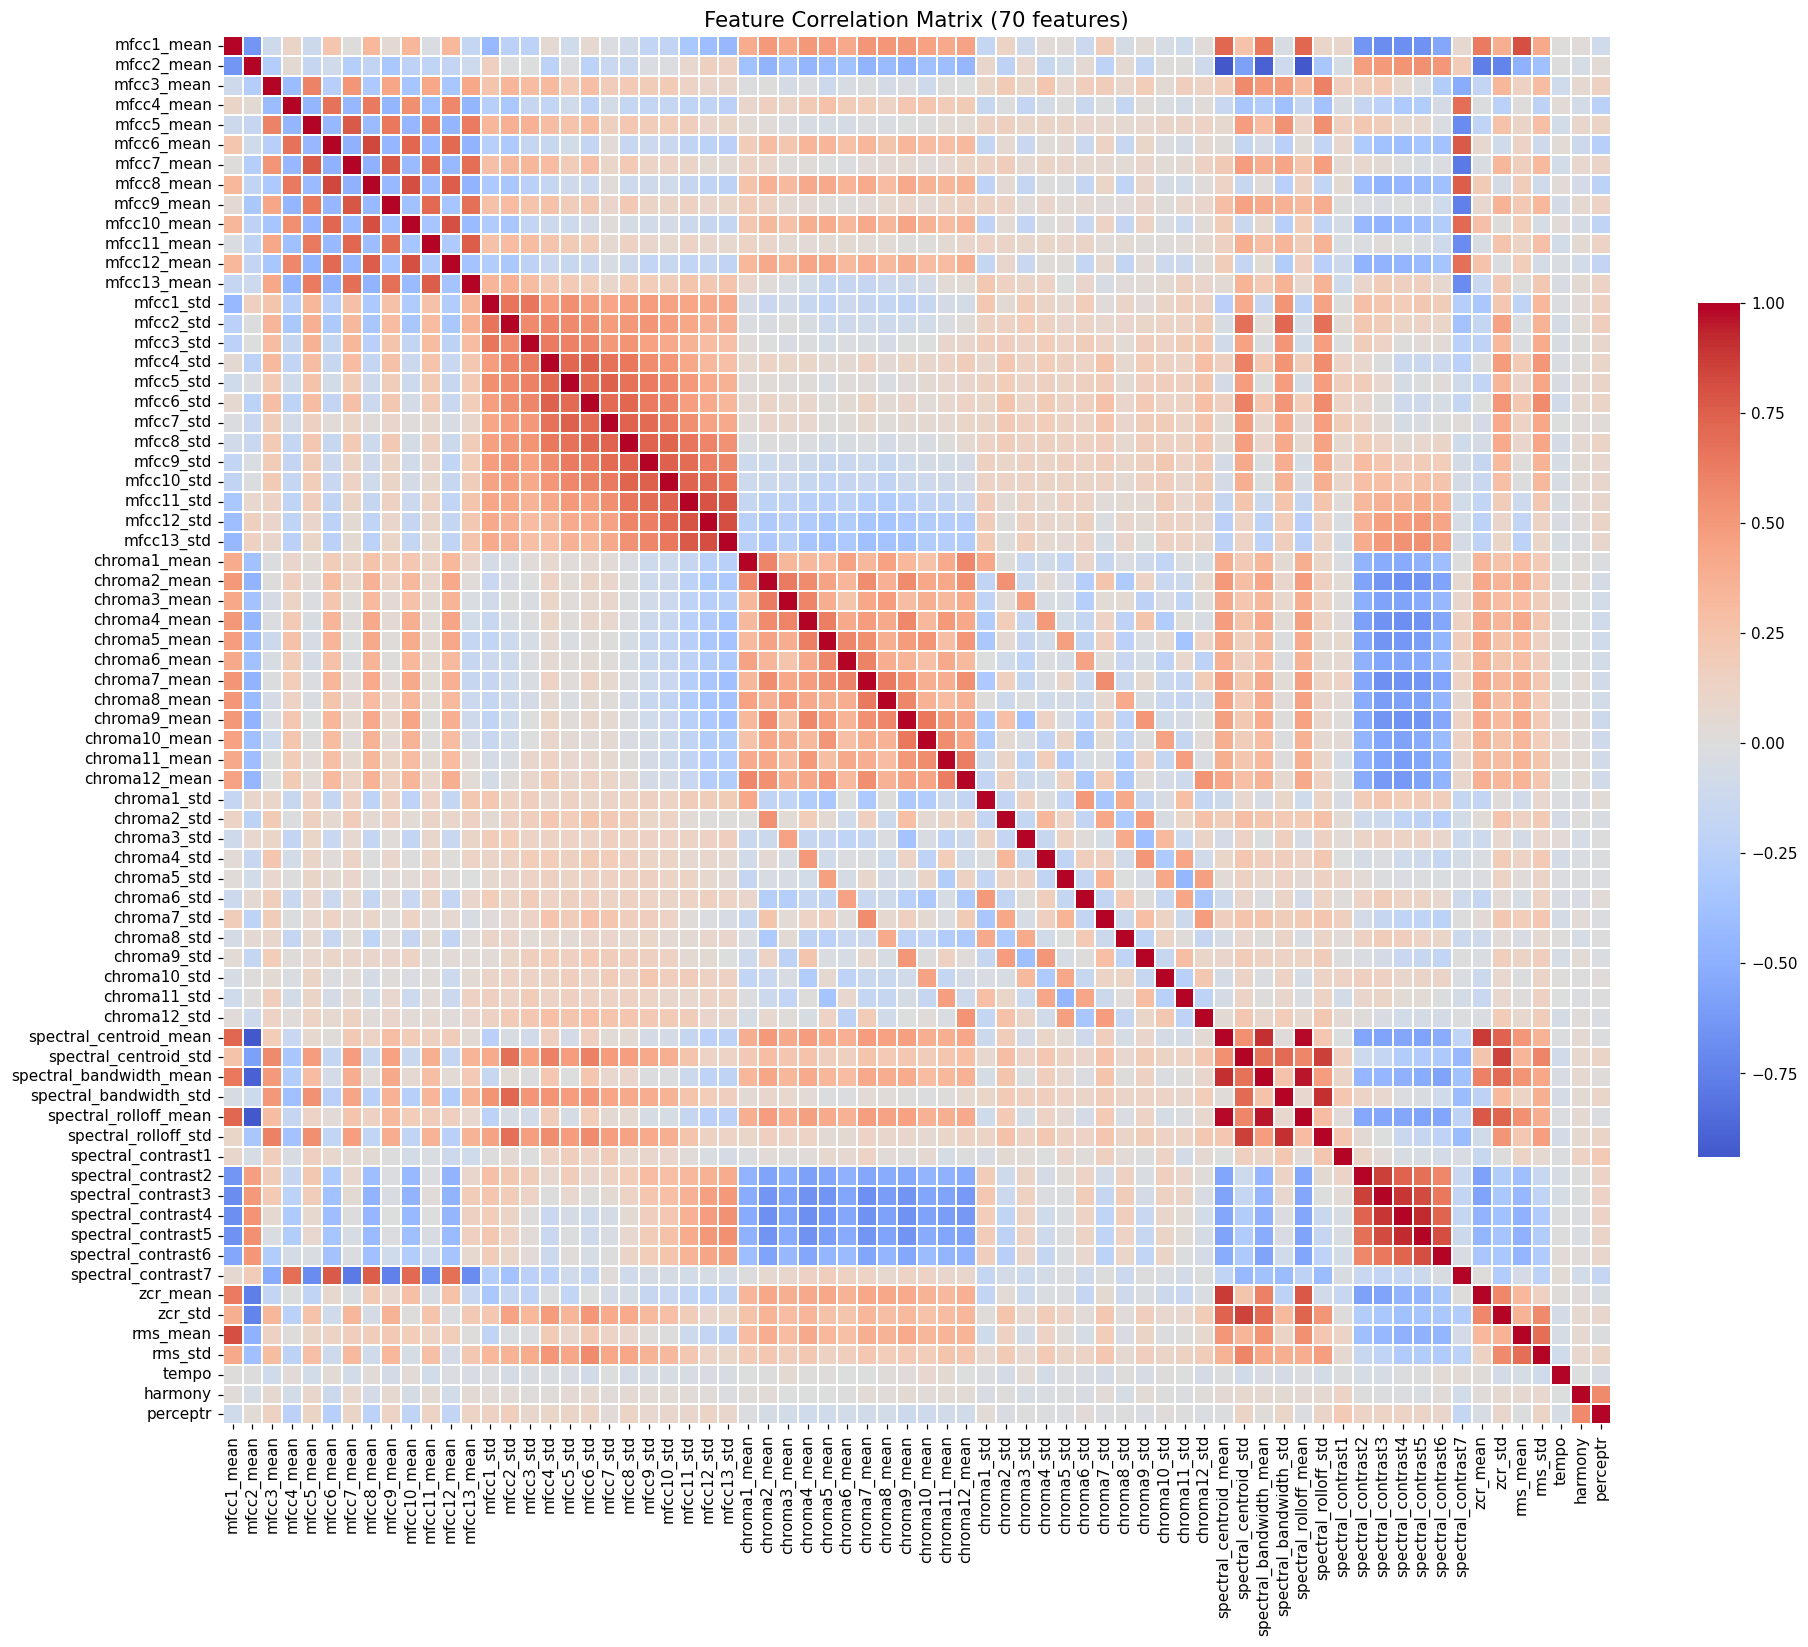


Feature pairs with |correlation| > 0.90: 7
  spectral_rolloff_mean               ↔ spectral_centroid_mean               r=0.980
  spectral_rolloff_mean               ↔ spectral_bandwidth_mean              r=0.956
  spectral_centroid_mean              ↔ mfcc2_mean                           r=-0.940
  spectral_rolloff_mean               ↔ mfcc2_mean                           r=-0.934
  spectral_contrast5                  ↔ spectral_contrast4                   r=0.920
  spectral_bandwidth_mean             ↔ spectral_centroid_mean               r=0.905
  spectral_rolloff_std                ↔ spectral_bandwidth_std               r=0.904


In [5]:
numeric_df = df[feature_cols].select_dtypes(include=["number"])
corr = numeric_df.corr()

plt.figure(figsize=(18, 15))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.1,
            cbar_kws={"shrink": 0.6}, square=True)
plt.title("Feature Correlation Matrix (70 features)", fontsize=14)
plt.tight_layout()
plt.show()

# Identify highly correlated pairs
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [(c, r, upper.loc[r, c]) for c in upper.columns
             for r in upper.index if abs(upper.loc[r, c]) > 0.90]
print(f"\nFeature pairs with |correlation| > 0.90: {len(high_corr)}")
for c, r, v in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True)[:10]:
    print(f"  {c:<35} ↔ {r:<35}  r={v:.3f}")

---
## 5 · MFCC Heatmap by Genre

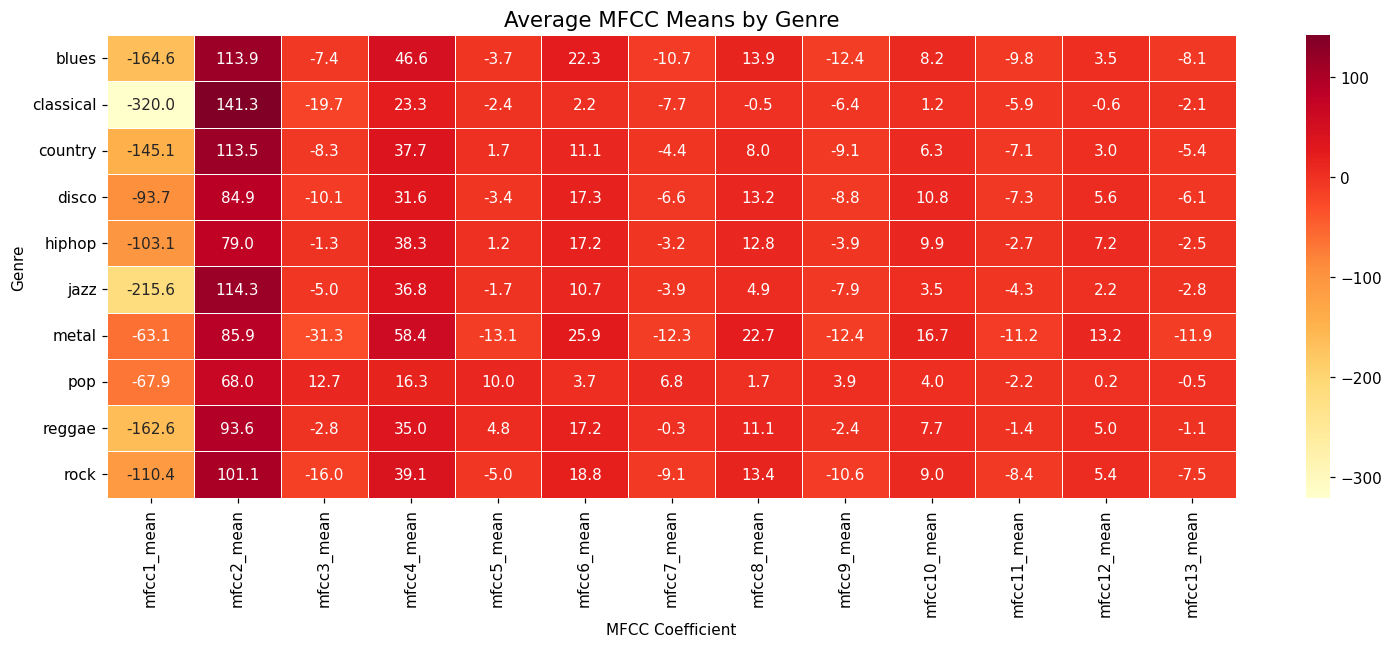

In [6]:
mfcc_all = [c for c in df.columns if "mfcc" in c and "mean" in c]
genre_mfcc = df.groupby("genre")[mfcc_all].mean()

plt.figure(figsize=(14, 6))
sns.heatmap(genre_mfcc, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5)
plt.title("Average MFCC Means by Genre", fontsize=14)
plt.ylabel("Genre")
plt.xlabel("MFCC Coefficient")
plt.tight_layout()
plt.show()

---
## 6 · Pairplot — Selected Features

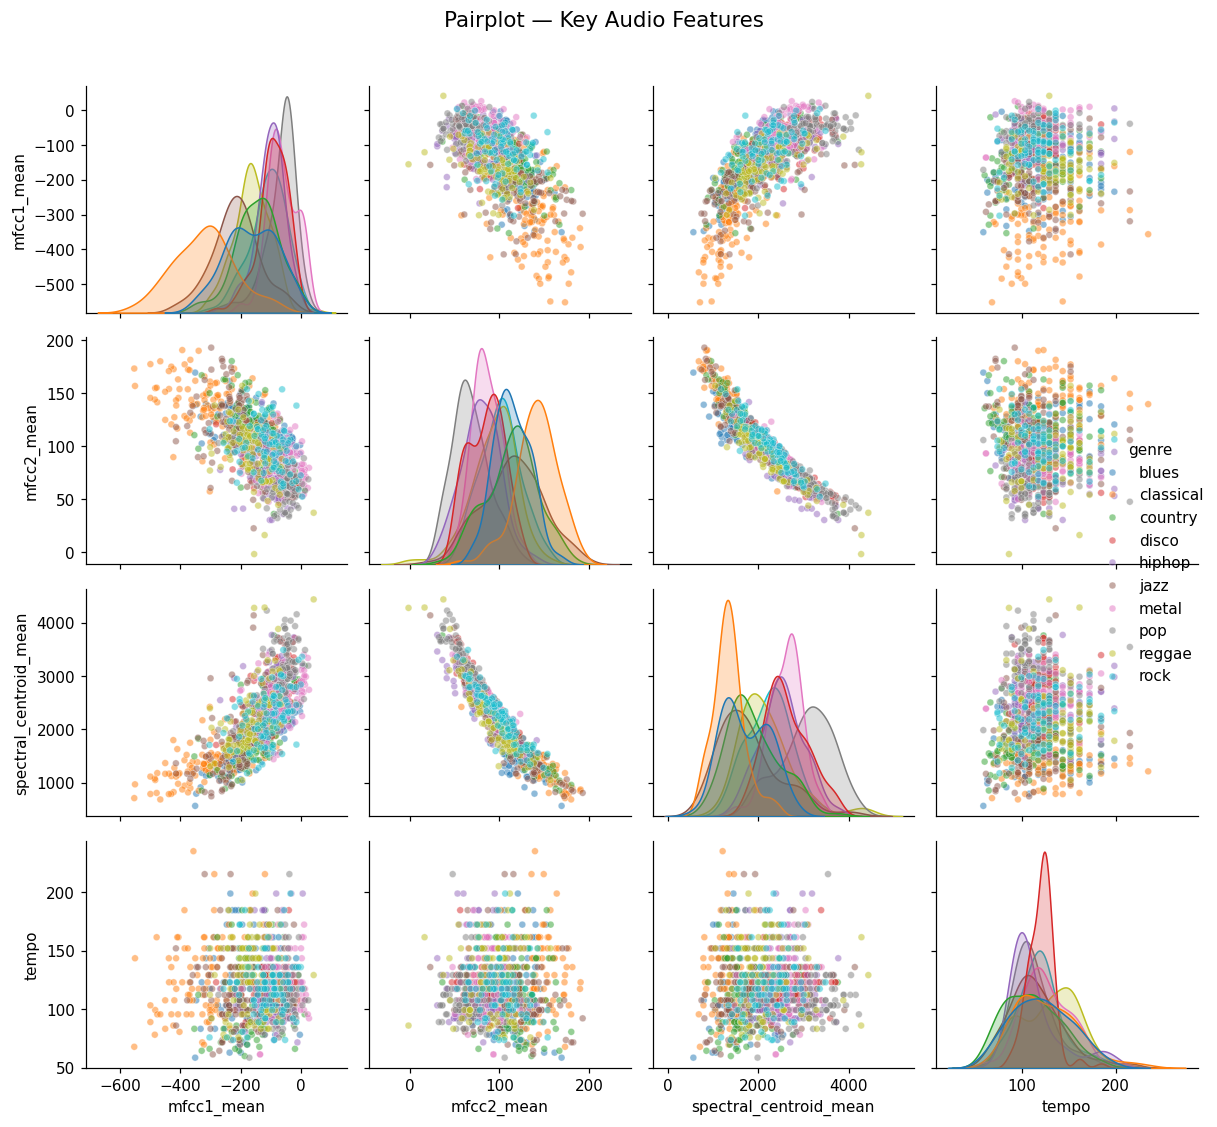

In [7]:
subset_cols = ["mfcc1_mean", "mfcc2_mean", "spectral_centroid_mean", "tempo", "genre"]
existing_sub = [c for c in subset_cols if c in df.columns]

if len(existing_sub) >= 3:
    sns.pairplot(df[existing_sub], hue="genre", diag_kind="kde",
                 plot_kws={"alpha": 0.5, "s": 20})
    plt.suptitle("Pairplot — Key Audio Features", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

---
## Summary

### Key Findings from Feature Analysis

| Finding | Implication |
|---|---|
| MFCC1 (energy) separates metal/rock (high) from classical/jazz (low) | Strong discriminative feature |
| Spectral centroid is high for metal, low for classical | Pitch brightness is genre-specific |
| Tempo clearly separates disco/hiphop from classical | Rhythmic features matter |
| Chroma and MFCC pairs are highly correlated (r > 0.90) | PCA or regularised models handle this well |
| Classical vs Jazz are the most similar profiles | Hardest pair to classify |

### Separability

The pairplot shows that no single feature perfectly separates all 10 genres, but combinations
of MFCC1, spectral centroid, and tempo create useful cluster boundaries. Tree-based models
and SVMs are well-suited to find non-linear decision boundaries in this space.

**Next**: `04_tabular_models.ipynb` — train and compare 6 classical ML classifiers.